# Emissions Analysis

**Purpose:** Descriptive panel analysis of Scope 1 and Scope 2 GHG emissions (2010–2023).

Covers:
- Winsorized time trends (overall, by scope type, by firm type)
- Firm size splits — large vs. small (uses `facility_count` as proxy until market cap / total assets fetched from Refinitiv)
- Grid factor subgroups — high vs. low state electricity emissions intensity
- Firm factor subgroups — high vs. low direct emissions intensity
- Fama-French 12 industry classification (requires SIC codes — see Section 5)

**Primary data:** `scope2_final.csv`  
**No regressions.**

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plot styling ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'legend.fontsize':  10,
})
PALETTE   = sns.color_palette('Set2', 6)
MARKERS   = ['o', 's', '^', 'D', 'v', 'P']
LINEWIDTH = 2.2

S1_COLOR = PALETTE[0]   # Scope 1 green
S2_COLOR = PALETTE[2]   # Scope 2 blue

MIN_N = 10   # minimum reporters per group-year to include in a plot

# Set True to export figures as PNG files into figures/
SAVE_FIGS = True
FIG_DIR   = 'figures'

import os
if SAVE_FIGS:
    os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    if SAVE_FIGS:
        plt.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight')

## 1. Data Loading

In [2]:
df = pd.read_csv('data/scope2_final.csv', low_memory=False)

# Numeric coercion for key columns
for col in ['scope1_location_total', 'scope2_final', 'scope2_location',
            'scope2_egrid_calculated', 'energy_use_total_mwh',
            'egrid_ef_lb_per_mwh', 'facility_count', 'year']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['gvkey'] = df['gvkey'].astype(str).str.strip()

# Drop rows with no year
df = df[df['year'].notna()].copy()
df['year'] = df['year'].astype(int)

print(f"Rows       : {len(df):>10,}")
print(f"Unique firms: {df['gvkey'].nunique():>9,}")
print(f"Year range : {df['year'].min()} – {df['year'].max()}")
print()
print("Scope 2 source breakdown:")
print(df['scope2_source'].value_counts(dropna=False).to_string())

Rows       :     80,633
Unique firms:     5,040
Year range : 1993 – 2025

Scope 2 source breakdown:
scope2_source
none                 72640
reported_location     7738
egrid_calculated       255


## 2. Financial Data — Market Cap & Total Assets

**To do:** Pull `TR.F.TotAssets` (Total Assets) and `TR.F.MktCap` (Market Cap) for all
instruments in `extraction/lseg_with_compustat.csv` via LSEG Workspace, then save as
`financial_data.csv` with columns `gvkey`, `year`, `total_assets`, `market_cap`.

Until that data is available, `log(facility_count + 1)` is used as a firm-size proxy.

In [3]:
# ── Merge financial data when available ───────────────────────────────────────
FIN_FILE = 'financials_checkpoint.csv'   # <-- create this file from Refinitiv

if os.path.exists(FIN_FILE):
    fin = pd.read_csv(FIN_FILE, low_memory=False)
    fin['gvkey'] = fin['gvkey'].astype(str).str.strip()
    fin['year']  = fin['year'].astype(int)
    for col in ['total_assets', 'market_cap']:
        fin[col] = pd.to_numeric(fin[col], errors='coerce')
    df = df.merge(fin[['gvkey', 'year', 'total_assets', 'market_cap']],
                  on=['gvkey', 'year'], how='left')
    SIZE_COL       = 'total_assets'
    SIZE_LABEL     = 'Total Assets (USD)'
    SIZE_LOG_COL   = 'log_total_assets'
    df[SIZE_LOG_COL] = np.log1p(df[SIZE_COL].clip(lower=0))
    print(f"Financial data merged. Coverage: {df[SIZE_COL].notna().mean():.1%}")
else:
    # Proxy: log(facility_count + 1)
    SIZE_COL       = 'facility_count'
    SIZE_LABEL     = 'Facility Count (proxy for size)'
    SIZE_LOG_COL   = 'log_facilities'
    df[SIZE_LOG_COL] = np.log1p(df[SIZE_COL].fillna(0))
    print(f"[!] financial_data.csv not found — using log(facility_count) as size proxy.")
    print(f"    Replace with total_assets or market_cap from Refinitiv when available.")

[!] financial_data.csv not found — using log(facility_count) as size proxy.
    Replace with total_assets or market_cap from Refinitiv when available.


## 3. Winsorization

All continuous emission and financial variables are winsorized at the 1st and 99th
percentile to limit the influence of extreme outliers. Winsorized versions carry the
suffix `_w` and are used for all subsequent analysis and plots.

In [4]:
WIN_LOWER = 0.01
WIN_UPPER = 0.99

def winsorize_series(s, lower=WIN_LOWER, upper=WIN_UPPER):
    """Clip series to [lower, upper] quantile range (ignoring NaN)."""
    q_lo = s.quantile(lower)
    q_hi = s.quantile(upper)
    return s.clip(lower=q_lo, upper=q_hi)

WIN_COLS = {
    'scope1_location_total':  'Scope 1 (mtCO2e)',
    'scope2_final':           'Scope 2 Final (mtCO2e)',
    'scope2_egrid_calculated':'Scope 2 eGRID Calc (mtCO2e)',
    'energy_use_total_mwh':   'Energy Use (MWh)',
}

if os.path.exists(FIN_FILE):
    WIN_COLS['total_assets'] = 'Total Assets (USD)'
    WIN_COLS['market_cap']   = 'Market Cap (USD)'

print(f"{'Column':<35} {'Raw P1':>12} {'Raw P99':>12} {'Win P99':>12} {'N non-NaN':>12}")
print('-' * 85)
for col, label in WIN_COLS.items():
    if col not in df.columns:
        continue
    s = df[col].dropna()
    if len(s) == 0:
        continue
    w = winsorize_series(s)
    df[f'{col}_w'] = winsorize_series(df[col])
    print(f"{label:<35} {s.quantile(0.01):>12,.0f} {s.quantile(0.99):>12,.0f} "
          f"{w.max():>12,.0f} {len(s):>12,}")

# Bug 8: Re-winsorize scope2_final_w using reported_location bounds only.
# eGRID-calculated values can be 50-100x larger than reported values due to
# implausible energy_use_total_mwh inputs, which inflates the shared upper tail.
if 'scope2_final' in df.columns and 'scope2_source' in df.columns:
    reported_mask = df['scope2_source'] == 'reported_location'
    q_lo = df.loc[reported_mask, 'scope2_final'].quantile(WIN_LOWER)
    q_hi = df.loc[reported_mask, 'scope2_final'].quantile(WIN_UPPER)
    df['scope2_final_w'] = df['scope2_final'].clip(lower=q_lo, upper=q_hi)
    df.loc[~reported_mask, 'scope2_final_w'] = np.nan
    print(f"\n[scope2_final_w overridden] reported_location-only bounds: "
          f"[{q_lo:,.0f}, {q_hi:,.0f}]")

Column                                    Raw P1      Raw P99      Win P99    N non-NaN
-------------------------------------------------------------------------------------
Scope 1 (mtCO2e)                               0   97,512,592   97,512,592       80,633
Scope 2 Final (mtCO2e)                         2   17,603,106   17,603,106        7,993
Scope 2 eGRID Calc (mtCO2e)                5,733  538,180,431  538,180,431          882
Energy Use (MWh)                           1,202  540,740,684  540,740,684       12,685

[scope2_final_w overridden] reported_location-only bounds: [1, 5,518,366]


## 4. Grid Factor & Firm Factor

**Grid factor** (`egrid_ef_lb_per_mwh`): State-level electricity emissions intensity (lb CO2e / MWh).
Captures how carbon-dirty the local electricity grid is — a property of the firm's *location*,
not its own operations.

**Firm factor** (Scope 1 / Energy Use): Direct emissions intensity of the firm's operations,
independent of the electricity grid. Measures how carbon-intensive the firm itself is.

Each factor is split into **High / Low** groups around the sample median to enable subgroup analysis.

In [5]:
# ── Grid Factor ───────────────────────────────────────────────────────────────
df['grid_factor'] = df['egrid_ef_lb_per_mwh']
grid_median = df['grid_factor'].median()
df['grid_group'] = np.where(
    df['grid_factor'].isna(), None,
    np.where(df['grid_factor'] >= grid_median, 'High Grid', 'Low Grid')
)

# ── Firm Factor ───────────────────────────────────────────────────────────────
# Scope 1 (mtCO2e) / Energy Use (MWh) → lb CO2e-equivalent intensity
# Use winsorized values to avoid outlier-driven extremes
s1_w  = df['scope1_location_total_w']
eng_w = df['energy_use_total_mwh_w'].replace(0, np.nan)

df['firm_factor'] = (s1_w * 2204.62) / eng_w   # convert mtCO2e → lb, divide by MWh
firm_median = df['firm_factor'].median()
df['firm_group'] = np.where(
    df['firm_factor'].isna(), None,
    np.where(df['firm_factor'] >= firm_median, 'High Firm Factor', 'Low Firm Factor')
)

# ── Firm size quartiles (proxy until Refinitiv data available) ────────────────
size_vals = df[SIZE_LOG_COL].replace(0, np.nan).dropna()
q25, q75  = size_vals.quantile(0.25), size_vals.quantile(0.75)
def size_group(x):
    if pd.isna(x) or x == 0:
        return None
    if x <= q25:
        return 'Small'
    elif x <= q75:
        return 'Medium'
    else:
        return 'Large'
df['size_group'] = df[SIZE_LOG_COL].apply(size_group)

print("Grid group distribution:")
print(df['grid_group'].value_counts(dropna=False).to_string())
print("\nFirm factor group distribution:")
print(df['firm_group'].value_counts(dropna=False).to_string())
print("\nSize group distribution:")
print(df['size_group'].value_counts(dropna=False).to_string())

Grid group distribution:
grid_group
None         79207
High Grid      729
Low Grid       697

Firm factor group distribution:
firm_group
None                67948
High Firm Factor    12685

Size group distribution:
size_group
None      75895
Medium     2031
Small      1606
Large      1101


## 5. Fama-French 12 Industry Classification

Requires 4-digit **SIC codes** (field `sich` from Compustat / WRDS).  
The `Compustat_Identifiers.csv` in the extraction folder does not currently include SIC codes.

**To enable FF12 classification:**
1. Pull `gvkey` and `sich` (historical SIC) from Compustat via WRDS Compustat Fundamentals Annual.
2. Save as `sic_codes.csv` with columns `gvkey`, `sich`.
3. Uncomment the merge and `df['ff12'] = df['sich'].apply(assign_ff12)` line below.

The `assign_ff12` function is implemented and ready to use.

In [21]:
def assign_ff12(sic):
    """
    Fama-French 12 industry classification from 4-digit SIC code.
    Source: https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library/det_12_ind_port.html
    Healthcare takes precedence for SICs that appear in multiple category ranges.
    """
    if pd.isna(sic):
        return '12 Other'
    sic = int(sic)
    if (2830 <= sic <= 2836) or sic == 3693 or (3840 <= sic <= 3859) or (8000 <= sic <= 8099):
        return '10 Hlth'
    elif (1200 <= sic <= 1399) or (2900 <= sic <= 2999):
        return '4 Enrgy'
    elif (2800 <= sic <= 2829) or (2840 <= sic <= 2869):
        return '5 Chems'
    elif (3570 <= sic <= 3579) or (3660 <= sic <= 3699) or (3810 <= sic <= 3829) or \
         (7370 <= sic <= 7379) or sic == 7391 or (8711 <= sic <= 8713):
        return '6 BusEq'
    elif (4800 <= sic <= 4899):
        return '7 Telcm'
    elif (4900 <= sic <= 4949):
        return '8 Utils'
    elif (5000 <= sic <= 5999) or (7200 <= sic <= 7299) or (7600 <= sic <= 7699):
        return '9 Shops'
    elif (6000 <= sic <= 6999):
        return '11 Money'
    elif (100 <= sic <= 999) or (2000 <= sic <= 2399) or (2700 <= sic <= 2749) or \
         (2770 <= sic <= 2799) or (3100 <= sic <= 3199) or (3940 <= sic <= 3989):
        return '1 NoDur'
    elif (2500 <= sic <= 2519) or (2590 <= sic <= 2599) or (3630 <= sic <= 3659) or \
         sic in [3710, 3711, 3714, 3716] or (3750 <= sic <= 3751) or sic == 3792 or \
         (3900 <= sic <= 3939) or (3990 <= sic <= 3999):
        return '2 Durbl'
    elif (2520 <= sic <= 2589) or (2600 <= sic <= 2699) or (2750 <= sic <= 2769) or \
         (3000 <= sic <= 3099) or (3200 <= sic <= 3569) or (3580 <= sic <= 3629) or \
         (3700 <= sic <= 3709) or sic in [3712, 3713, 3715] or (3717 <= sic <= 3749) or \
         (3752 <= sic <= 3791) or (3793 <= sic <= 3799) or (3830 <= sic <= 3839) or \
         (3860 <= sic <= 3899):
        return '3 Manuf'
    else:
        return '12 Other'

FF12_LABELS = {
    '1 NoDur':  'Consumer NonDurables',
    '2 Durbl':  'Consumer Durables',
    '3 Manuf':  'Manufacturing',
    '4 Enrgy':  'Energy',
    '5 Chems':  'Chemicals',
    '6 BusEq':  'Business Equipment',
    '7 Telcm':  'Telecom',
    '8 Utils':  'Utilities',
    '9 Shops':  'Retail / Shops',
    '10 Hlth':  'Healthcare',
    '11 Money': 'Finance',
    '12 Other': 'Other',
}

SIC_FILE = 'data/sic_codes.csv'
if os.path.exists(SIC_FILE):
    sic_df = pd.read_csv(SIC_FILE)
    sic_df['gvkey'] = sic_df['gvkey'].astype(str).str.strip()
    sic_df['sich']  = pd.to_numeric(sic_df['sich'], errors='coerce')
    sic_df = sic_df.dropna(subset=['sich']).drop_duplicates('gvkey')
    df = df.merge(sic_df[['gvkey', 'sich']], on='gvkey', how='left')
    df['ff12'] = df['sich'].apply(assign_ff12)
    df['ff12_label'] = df['ff12'].map(FF12_LABELS).fillna('Other')
    print("FF12 classification applied:")
    print(df['ff12_label'].value_counts().to_string())
else:
    df['ff12']       = '12 Other'
    df['ff12_label'] = 'Other'
    print("[!] sic_codes.csv not found. FF12 industry charts will show 'Other' for all firms.")
    print("    Pull 'gvkey' + 'sich' from Compustat (WRDS) and save as sic_codes.csv.")

FF12 classification applied:
ff12_label
Other                   67153
Finance                  4149
Healthcare               2321
Business Equipment       2129
Retail / Shops            975
Energy                    901
Manufacturing             899
Telecom                   660
Utilities                 506
Consumer NonDurables      420
Chemicals                 284
Consumer Durables         236


## 6. Figure 1 — Overall Time Trends

Mean and median winsorized emissions per year across all firms.  
The gap between mean and median reflects skewness even after winsorization.

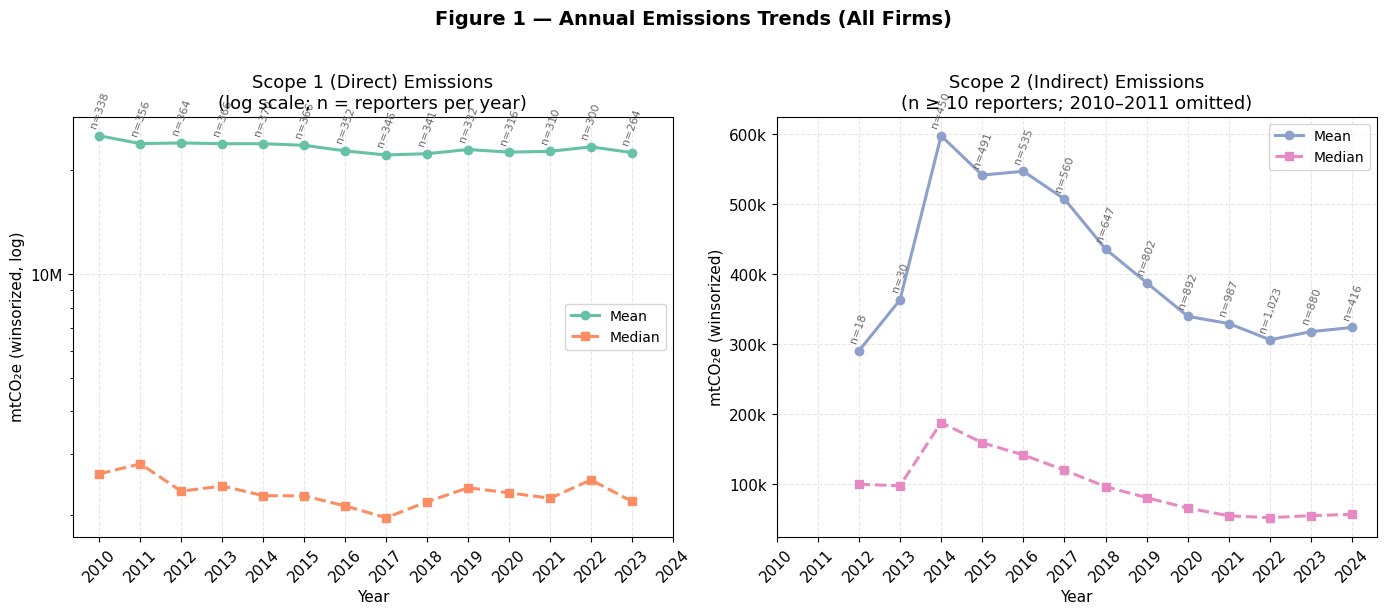

In [7]:
# Bug 10: explicit range ensures 2024 is included; Scope 1 2024 NaN-fills naturally
years_all = list(range(2010, 2025))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# ── Scope 1 panel — log scale (Bug 1) ────────────────────────────────────────
ax = axes[0]
col = 'scope1_location_total_w'
s1_sub = df[(df[col].notna()) & (df[col] > 0) & df['year'].isin(years_all)]
s1_grp = s1_sub.groupby('year')[col].agg(['mean', 'median', 'count']).reindex(years_all)

ax.plot(s1_grp.index, s1_grp['mean'],   'o-',  color=S1_COLOR,  lw=LINEWIDTH, label='Mean',   markersize=6)
ax.plot(s1_grp.index, s1_grp['median'], 's--', color=PALETTE[1], lw=LINEWIDTH, label='Median', markersize=6)

ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}'
))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

# n-labels rotated 70° to avoid overlap
for yr, row in s1_grp.iterrows():
    if pd.notna(row['mean']) and row['mean'] > 0:
        ax.annotate(f"n={int(row['count']):,}", xy=(yr, row['mean']),
                    xytext=(0, 6), textcoords='offset points',
                    ha='center', fontsize=8, rotation=70, color='dimgray')

ax.set_title('Scope 1 (Direct) Emissions\n(log scale; n = reporters per year)')
ax.set_xlabel('Year')
ax.set_ylabel('mtCO\u2082e (winsorized, log)')
ax.legend()
ax.set_xticks(years_all)
ax.tick_params(axis='x', rotation=45)

# ── Scope 2 panel — linear, reported_location only, n ≥ MIN_N (Bug 9) ────────
ax = axes[1]
col = 'scope2_final_w'
s2_rep = df[(df['scope2_source'] == 'reported_location') & df['year'].isin(years_all)]
s2_n   = s2_rep.groupby('year')[col].count().reindex(years_all).fillna(0).astype(int)

# Bug 9: dynamically compute which years are omitted
omitted = sorted(s2_n[s2_n < MIN_N].index.tolist())
omit_str = f"{omitted[0]}\u2013{omitted[-1]}" if omitted else "none"
subtitle  = f"(n \u2265 {MIN_N} reporters; {omit_str} omitted)"

valid_yrs = s2_n[s2_n >= MIN_N].index
s2_grp = s2_rep[s2_rep['year'].isin(valid_yrs)].groupby('year')[col].agg(['mean', 'median']).reindex(valid_yrs).sort_index()

ax.plot(s2_grp.index, s2_grp['mean'],   'o-',  color=S2_COLOR,  lw=LINEWIDTH, label='Mean',   markersize=6)
ax.plot(s2_grp.index, s2_grp['median'], 's--', color=PALETTE[3], lw=LINEWIDTH, label='Median', markersize=6)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}'
))

# n-labels
for yr in valid_yrs:
    n = int(s2_n.get(yr, 0))
    mean_val = s2_grp.loc[yr, 'mean'] if yr in s2_grp.index else np.nan
    if n > 0 and pd.notna(mean_val):
        ax.annotate(f"n={n:,}", xy=(yr, mean_val),
                    xytext=(0, 6), textcoords='offset points',
                    ha='center', fontsize=8, rotation=70, color='dimgray')

ax.set_title(f'Scope 2 (Indirect) Emissions\n{subtitle}')
ax.set_xlabel('Year')
ax.set_ylabel('mtCO\u2082e (winsorized)')
ax.legend()
ax.set_xticks(years_all)
ax.tick_params(axis='x', rotation=45)

fig.suptitle('Figure 1 \u2014 Annual Emissions Trends (All Firms)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('fig1_overall_trends')
plt.show()

## 7. Figure 2 — Scope 1 vs. Scope 2 Combined Trends

Mean emissions per firm-year, plotted together to show the relative magnitudes of
direct vs. indirect emissions over the sample period.

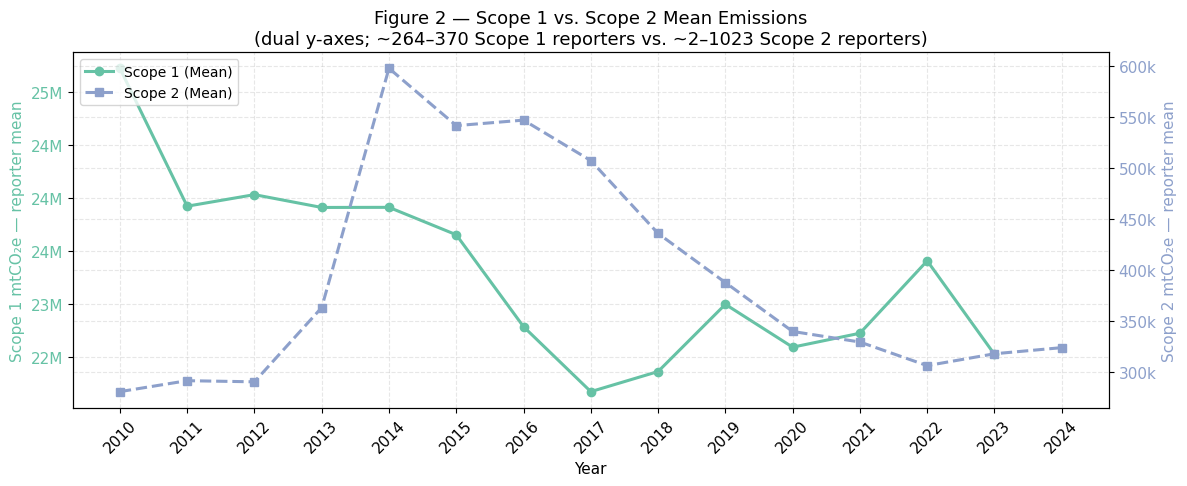

In [8]:
col1 = 'scope1_location_total_w'
col2 = 'scope2_final_w'

s1_grp = df[(df[col1].notna()) & (df[col1] > 0) & df['year'].isin(years_all)
            ].groupby('year')[col1].mean().reindex(years_all)
s2_grp = df[(df['scope2_source'] == 'reported_location') & df['year'].isin(years_all)
            ].groupby('year')[col2].mean().reindex(years_all)

# Reporter counts for subtitle
s1_n_by_yr = df[(df[col1] > 0) & df['year'].isin(years_all)]['year'].value_counts()
s2_n_by_yr = df[(df['scope2_source'] == 'reported_location') & df['year'].isin(years_all)]['year'].value_counts()
s1_rng = f"{s1_n_by_yr.min()}\u2013{s1_n_by_yr.max()}" if len(s1_n_by_yr) else "n/a"
s2_rng = f"{s2_n_by_yr.min()}\u2013{s2_n_by_yr.max()}" if len(s2_n_by_yr) else "n/a"

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

l1, = ax1.plot(years_all, s1_grp.values, 'o-',  color=S1_COLOR, lw=LINEWIDTH,
               label='Scope 1 (Mean)', markersize=6)
l2, = ax2.plot(years_all, s2_grp.values, 's--', color=S2_COLOR, lw=LINEWIDTH,
               label='Scope 2 (Mean)', markersize=6)

ax1.set_ylabel('Scope 1 mtCO\u2082e \u2014 reporter mean', color=S1_COLOR)
ax2.set_ylabel('Scope 2 mtCO\u2082e \u2014 reporter mean', color=S2_COLOR)
ax1.tick_params(axis='y', labelcolor=S1_COLOR)
ax2.tick_params(axis='y', labelcolor=S2_COLOR)

for ax in (ax1, ax2):
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}'
    ))

ax1.set_xlabel('Year')
ax1.set_xticks(years_all)
ax1.tick_params(axis='x', rotation=45)

ax1.set_title(
    'Figure 2 \u2014 Scope 1 vs. Scope 2 Mean Emissions\n'
    f'(dual y-axes; ~{s1_rng} Scope 1 reporters vs. ~{s2_rng} Scope 2 reporters)'
)
ax1.legend(handles=[l1, l2], loc='upper left')
plt.tight_layout()
savefig('fig2_scope1_vs_scope2')
plt.show()

## 8. Figure 3 — Firm Size Subgroups (Large vs. Small)

Firms split into Small / Medium / Large based on `log(facility_count + 1)` (proxy).
Replace `SIZE_LOG_COL` with `log_total_assets` or `log_market_cap` once Refinitiv data is available.

Shows whether larger firms have systematically higher emissions over time.

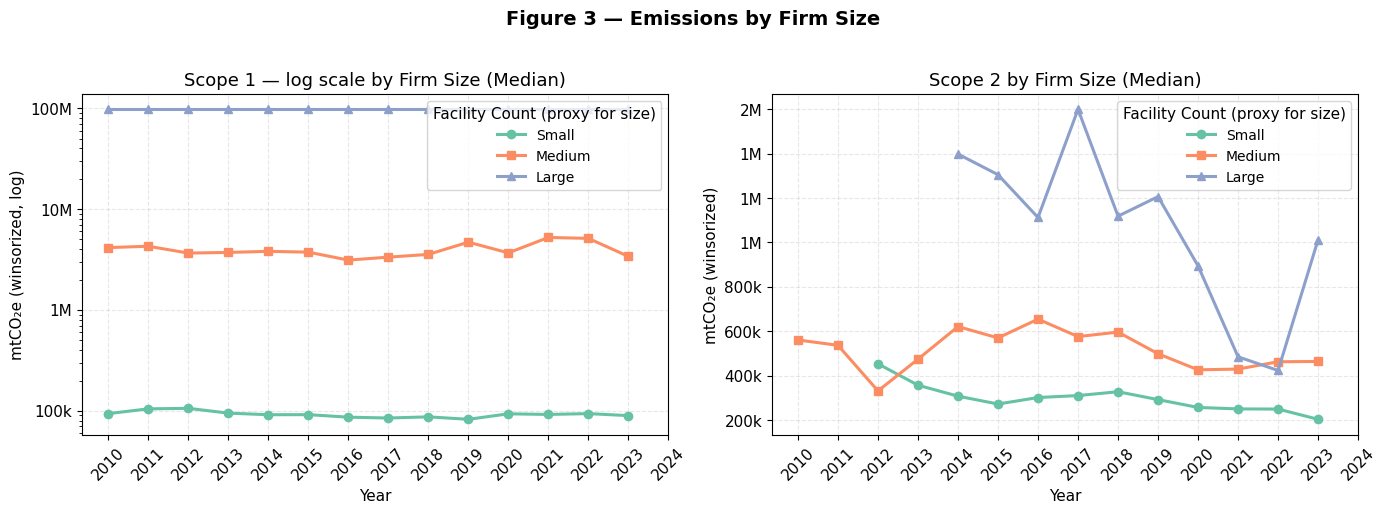

In [9]:
SIZE_GROUPS   = ['Small', 'Medium', 'Large']
SIZE_COLORS   = [PALETTE[0], PALETTE[1], PALETTE[2]]
SIZE_MARKERS  = ['o', 's', '^']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, col, title, use_log in zip(
    axes,
    ['scope1_location_total_w', 'scope2_final_w'],
    ['Scope 1 \u2014 log scale', 'Scope 2'],
    [True, False],
):
    if col not in df.columns:
        continue
    # Scope 1: reporters only; Scope 2: reported_location only (NaN after Bug 8 for others)
    sub = df[df['size_group'].notna() & df[col].notna() & (df[col] > 0) & df['year'].isin(years_all)]
    for grp, color, marker in zip(SIZE_GROUPS, SIZE_COLORS, SIZE_MARKERS):
        s = sub[sub['size_group'] == grp].groupby('year')[col].median().reindex(years_all)
        ax.plot(s.index, s.values, f'{marker}-', color=color, lw=LINEWIDTH, label=grp, markersize=6)
    ax.set_title(f'{title} by Firm Size (Median)')
    ax.set_xlabel('Year')
    if use_log:
        ax.set_yscale('log')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}'
        ))
        ax.yaxis.set_minor_formatter(mticker.NullFormatter())
        ax.set_ylabel('mtCO\u2082e (winsorized, log)')
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}'
        ))
        ax.set_ylabel('mtCO\u2082e (winsorized)')
    ax.legend(title=SIZE_LABEL)
    ax.set_xticks(years_all)
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Figure 3 \u2014 Emissions by Firm Size', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('fig3_size_trends')
plt.show()

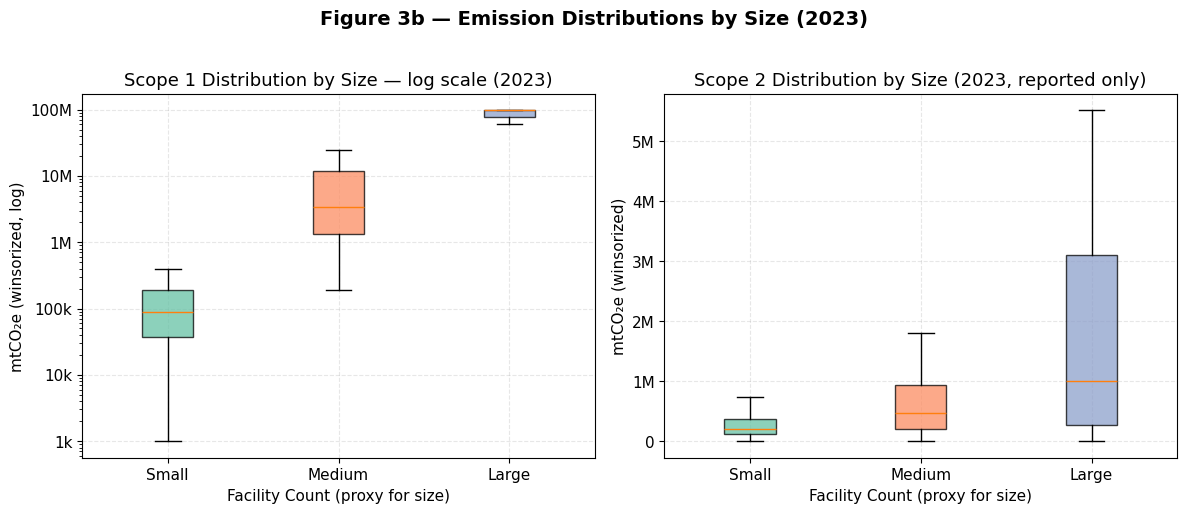

In [10]:
# Dynamically pick latest year that has scope2+size_group overlap
SNAPSHOT_YEAR = max(
    (yr for yr in years_all
     if len(df[(df['year'] == yr) &
               (df['scope2_source'] == 'reported_location') &
               df['size_group'].notna() &
               df['scope2_final_w'].notna()]) > 0),
    default=max(years_all)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Scope 1 boxplot — log scale, reporters only ───────────────────────────────
ax = axes[0]
col = 'scope1_location_total_w'
scope1_snap = df[
    (df['year'] == SNAPSHOT_YEAR) &
    df['size_group'].notna() &
    df[col].notna() &
    (df[col] > 0)
].copy()

if len(scope1_snap) == 0:
    ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
else:
    box_data   = [scope1_snap[scope1_snap['size_group'] == g][col].values for g in SIZE_GROUPS]
    valid_idx  = [i for i, d in enumerate(box_data) if len(d) > 0]
    box_data   = [box_data[i] for i in valid_idx]
    valid_grps = [SIZE_GROUPS[i] for i in valid_idx]
    valid_cols = [SIZE_COLORS[i] for i in valid_idx]
    bp = ax.boxplot(box_data, labels=valid_grps, patch_artist=True, showfliers=False)
    for patch, color in zip(bp['boxes'], valid_cols):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}'
    ))
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_title(f'Scope 1 Distribution by Size — log scale ({SNAPSHOT_YEAR})')
    ax.set_xlabel(SIZE_LABEL)
    ax.set_ylabel('mtCO₂e (winsorized, log)')

# ── Scope 2 boxplot — reported_location only (Bug 4) ─────────────────────────
ax = axes[1]
col = 'scope2_final_w'
scope2_snap = df[
    (df['year'] == SNAPSHOT_YEAR) &
    (df['scope2_source'] == 'reported_location') &
    df['size_group'].notna() &
    df[col].notna()
].copy()

if len(scope2_snap) == 0:
    ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
else:
    box_data   = [scope2_snap[scope2_snap['size_group'] == g][col].values for g in SIZE_GROUPS]
    valid_idx  = [i for i, d in enumerate(box_data) if len(d) > 0]
    box_data   = [box_data[i] for i in valid_idx]
    valid_grps = [SIZE_GROUPS[i] for i in valid_idx]
    valid_cols = [SIZE_COLORS[i] for i in valid_idx]
    bp = ax.boxplot(box_data, labels=valid_grps, patch_artist=True, showfliers=False)
    for patch, color in zip(bp['boxes'], valid_cols):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}'
    ))
    ax.set_title(f'Scope 2 Distribution by Size ({SNAPSHOT_YEAR}, reported only)')
    ax.set_xlabel(SIZE_LABEL)
    ax.set_ylabel('mtCO₂e (winsorized)')

fig.suptitle(f'Figure 3b — Emission Distributions by Size ({SNAPSHOT_YEAR})',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('fig3b_size_boxplots')
plt.show()

## 9. Figure 4 — Grid Factor Subgroups (High vs. Low)

**Grid factor** = state-level electricity emissions intensity (`egrid_ef_lb_per_mwh`, lb CO2e / MWh).  
- **High Grid** firms are in states with dirtier electricity (e.g., coal-heavy states).
- **Low Grid** firms are in states with cleaner electricity (e.g., hydro/wind states).

This separates whether observed Scope 2 differences are driven by *where* firms are located
vs. *how much* electricity they consume.

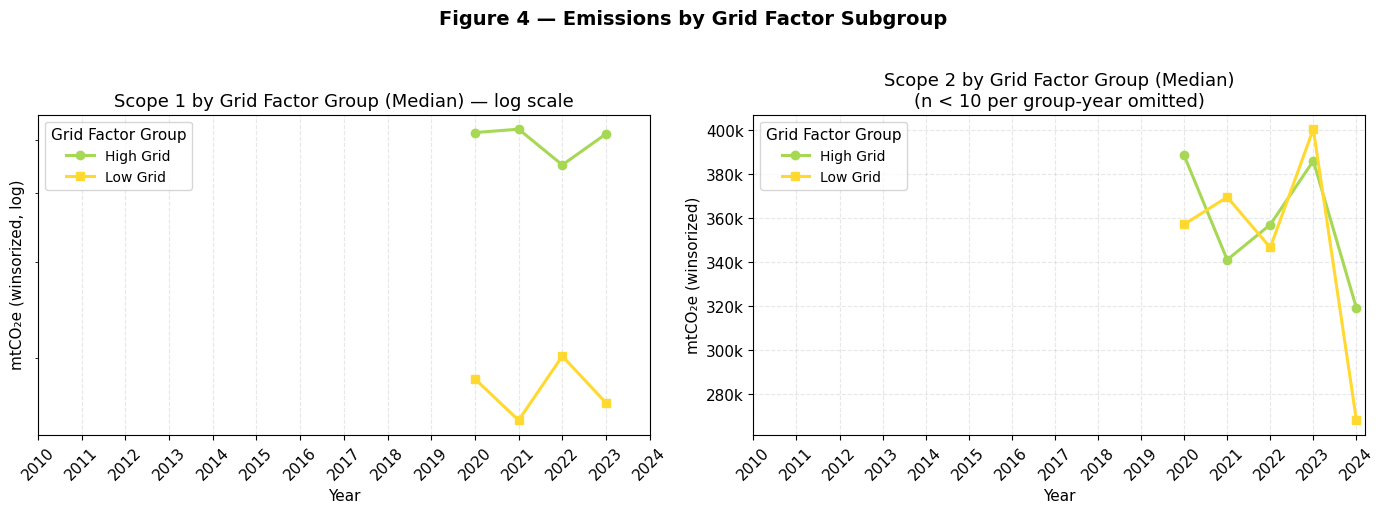

In [11]:
GRID_GROUPS  = ['High Grid', 'Low Grid']
GRID_COLORS  = [PALETTE[4], PALETTE[5]]
GRID_MARKERS = ['o', 's']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# ── Scope 1 — log scale (Bug 5) ──────────────────────────────────────────────
ax = axes[0]
col = 'scope1_location_total_w'
sub1 = df[df['grid_group'].notna() & (df[col] > 0) & df['year'].isin(years_all)]
for grp, color, marker in zip(GRID_GROUPS, GRID_COLORS, GRID_MARKERS):
    s = sub1[sub1['grid_group'] == grp].groupby('year')[col].median().reindex(years_all)
    ax.plot(s.index, s.values, f'{marker}-', color=color, lw=LINEWIDTH, label=grp, markersize=6)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}'
))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())
ax.set_title('Scope 1 by Grid Factor Group (Median) \u2014 log scale')
ax.set_xlabel('Year')
ax.set_ylabel('mtCO\u2082e (winsorized, log)')
ax.legend(title='Grid Factor Group')
ax.set_xticks(years_all)
ax.tick_params(axis='x', rotation=45)

# ── Scope 2 — n ≥ MIN_N filter (Bug 6) ───────────────────────────────────────
ax = axes[1]
col = 'scope2_final_w'
sub2 = df[df['grid_group'].notna() & (df['scope2_source'] == 'reported_location') &
          df[col].notna() & df['year'].isin(years_all)]
for grp, color, marker in zip(GRID_GROUPS, GRID_COLORS, GRID_MARKERS):
    grp_df   = sub2[sub2['grid_group'] == grp]
    s_counts = grp_df.groupby('year')[col].count().reindex(years_all).fillna(0)
    s        = grp_df.groupby('year')[col].median().reindex(years_all)
    s[s_counts < MIN_N] = np.nan
    ax.plot(s.index, s.values, f'{marker}-', color=color, lw=LINEWIDTH, label=grp, markersize=6)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}'
))
ax.set_title(f'Scope 2 by Grid Factor Group (Median)\n(n < {MIN_N} per group-year omitted)')
ax.set_xlabel('Year')
ax.set_ylabel('mtCO\u2082e (winsorized)')
ax.legend(title='Grid Factor Group')
ax.set_xticks(years_all)
ax.tick_params(axis='x', rotation=45)

fig.suptitle('Figure 4 \u2014 Emissions by Grid Factor Subgroup', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('fig4_grid_factor_trends')
plt.show()

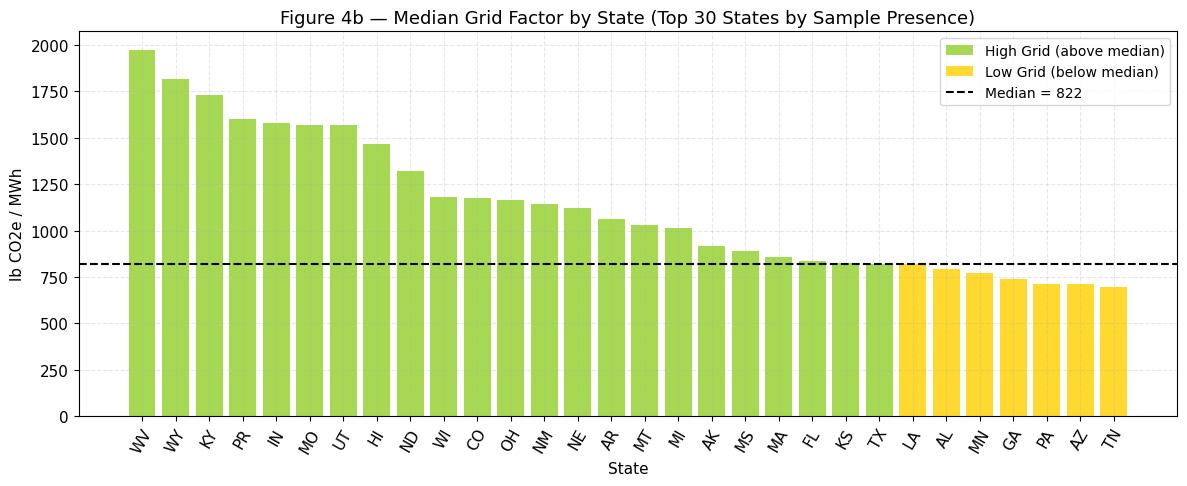

In [12]:
# Grid factor by state — show which states land in each group
state_grid_avg = (
    df[df['grid_factor'].notna()]
    .groupby('primary_state')['grid_factor']
    .median()
    .sort_values(ascending=False)
    .head(30)
)

fig, ax = plt.subplots(figsize=(12, 5))
colors = [PALETTE[4] if v >= grid_median else PALETTE[5] for v in state_grid_avg.values]
ax.bar(state_grid_avg.index, state_grid_avg.values, color=colors)
ax.axhline(grid_median, color='black', lw=1.5, linestyle='--', label=f'Median = {grid_median:.0f}')
ax.set_title('Figure 4b — Median Grid Factor by State (Top 30 States by Sample Presence)')
ax.set_xlabel('State')
ax.set_ylabel('lb CO2e / MWh')
ax.tick_params(axis='x', rotation=60)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=PALETTE[4], label='High Grid (above median)'),
    Patch(facecolor=PALETTE[5], label='Low Grid (below median)'),
]
ax.legend(handles=legend_elements + [plt.Line2D([0], [0], color='black', lw=1.5,
           linestyle='--', label=f'Median = {grid_median:.0f}')])
plt.tight_layout()
savefig('fig4b_grid_by_state')
plt.show()

## 10. Figure 5 — Firm Factor Subgroups (High vs. Low)

**Firm factor** = Scope 1 / Energy Use (lb CO2e / MWh equivalent).  
Captures how carbon-intensive a firm's *own* operations are, independent of location.

- **High Firm Factor**: firm itself is carbon-intensive (e.g., heavy industry, chemicals).
- **Low Firm Factor**: firm has relatively clean direct operations (e.g., services, tech).

Compare High Firm Factor vs. Low Firm Factor within each Grid group for a 2×2 decomposition.

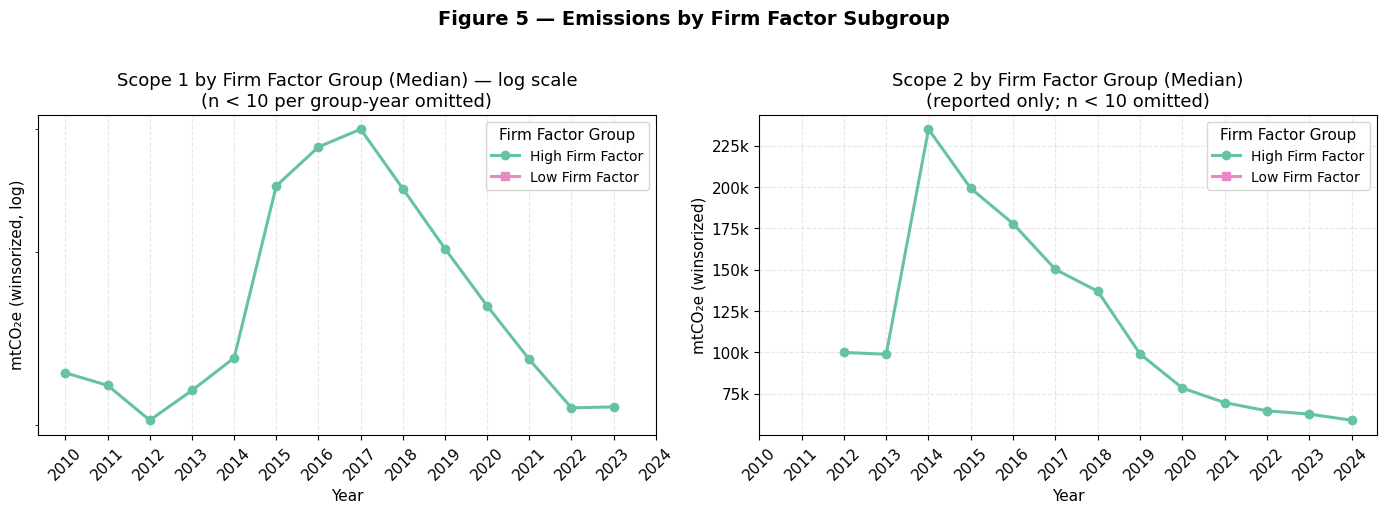

In [13]:
FIRM_GROUPS  = ['High Firm Factor', 'Low Firm Factor']
FIRM_COLORS  = [PALETTE[0], PALETTE[3]]
FIRM_MARKERS = ['o', 's']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# ── Scope 1 — log scale + n ≥ MIN_N (Bug 7) ─────────────────────────────────
ax = axes[0]
col = 'scope1_location_total_w'
sub1 = df[df['firm_group'].notna() & (df[col] > 0) & df['year'].isin(years_all)]
for grp, color, marker in zip(FIRM_GROUPS, FIRM_COLORS, FIRM_MARKERS):
    grp_df   = sub1[sub1['firm_group'] == grp]
    s_counts = grp_df.groupby('year')[col].count().reindex(years_all).fillna(0)
    s        = grp_df.groupby('year')[col].median().reindex(years_all)
    s[s_counts < MIN_N] = np.nan
    ax.plot(s.index, s.values, f'{marker}-', color=color, lw=LINEWIDTH, label=grp, markersize=6)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}'
))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())
ax.set_title(f'Scope 1 by Firm Factor Group (Median) \u2014 log scale\n(n < {MIN_N} per group-year omitted)')
ax.set_xlabel('Year')
ax.set_ylabel('mtCO\u2082e (winsorized, log)')
ax.legend(title='Firm Factor Group')
ax.set_xticks(years_all)
ax.tick_params(axis='x', rotation=45)

# ── Scope 2 — reported_location only + n ≥ MIN_N (Bug 7) ────────────────────
ax = axes[1]
col = 'scope2_final_w'
sub2 = df[df['firm_group'].notna() & (df['scope2_source'] == 'reported_location') &
          df[col].notna() & df['year'].isin(years_all)]
for grp, color, marker in zip(FIRM_GROUPS, FIRM_COLORS, FIRM_MARKERS):
    grp_df   = sub2[sub2['firm_group'] == grp]
    s_counts = grp_df.groupby('year')[col].count().reindex(years_all).fillna(0)
    s        = grp_df.groupby('year')[col].median().reindex(years_all)
    s[s_counts < MIN_N] = np.nan
    ax.plot(s.index, s.values, f'{marker}-', color=color, lw=LINEWIDTH, label=grp, markersize=6)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}'
))
ax.set_title(f'Scope 2 by Firm Factor Group (Median)\n(reported only; n < {MIN_N} omitted)')
ax.set_xlabel('Year')
ax.set_ylabel('mtCO\u2082e (winsorized)')
ax.legend(title='Firm Factor Group')
ax.set_xticks(years_all)
ax.tick_params(axis='x', rotation=45)

fig.suptitle('Figure 5 \u2014 Emissions by Firm Factor Subgroup', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('fig5_firm_factor_trends')
plt.show()

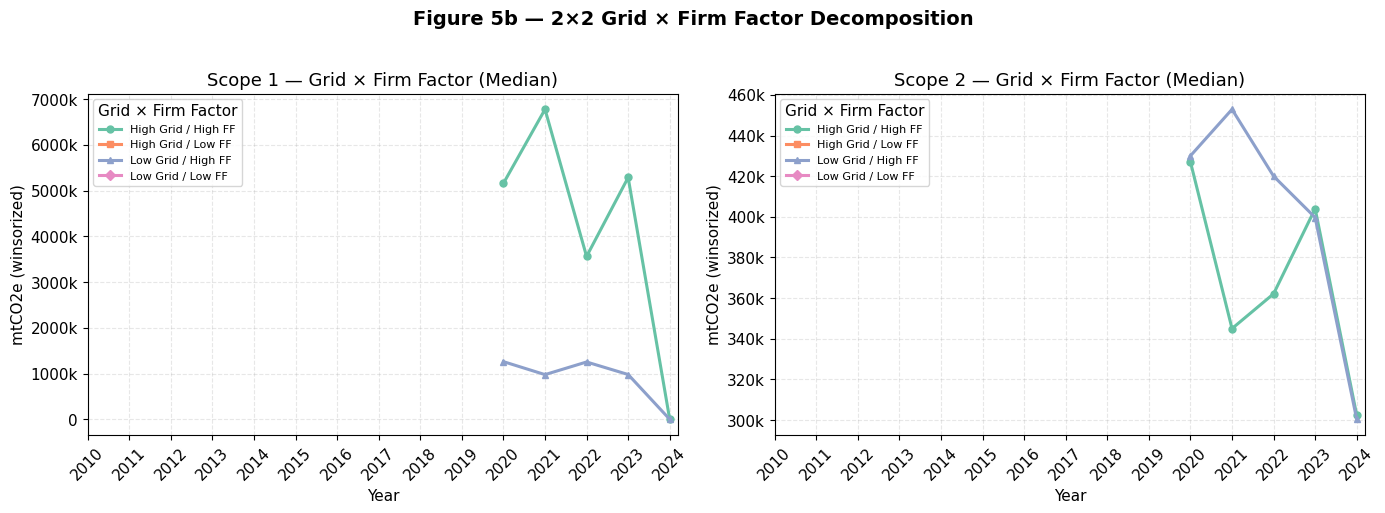

In [14]:
# 2×2 decomposition: Grid × Firm factor
df['grid_x_firm'] = np.where(
    df['grid_group'].isna() | df['firm_group'].isna(), np.nan,
    df['grid_group'] + ' / ' + df['firm_group'].str.replace('Firm Factor', 'FF')
)

CROSS_GROUPS = [
    'High Grid / High FF',
    'High Grid / Low FF',
    'Low Grid / High FF',
    'Low Grid / Low FF',
]
CROSS_COLORS  = [PALETTE[0], PALETTE[1], PALETTE[2], PALETTE[3]]
CROSS_MARKERS = ['o', 's', '^', 'D']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(
    axes,
    ['scope1_location_total_w', 'scope2_final_w'],
    ['Scope 1', 'Scope 2'],
):
    if col not in df.columns:
        continue
    sub = df[df['grid_x_firm'].notna() & df[col].notna()]
    for grp, color, marker in zip(CROSS_GROUPS, CROSS_COLORS, CROSS_MARKERS):
        s = sub[sub['grid_x_firm'] == grp].groupby('year')[col].median().reindex(years_all)
        ax.plot(s.index, s.values, f'{marker}-', color=color, lw=LINEWIDTH,
                label=grp, markersize=5)
    ax.set_title(f'{title} — Grid × Firm Factor (Median)')
    ax.set_xlabel('Year')
    ax.set_ylabel('mtCO2e (winsorized)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e3:.0f}k' if x >= 1000 else f'{x:.0f}'))
    ax.legend(title='Grid × Firm Factor', fontsize=8)
    ax.set_xticks(years_all)
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Figure 5b — 2×2 Grid × Firm Factor Decomposition', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('fig5b_grid_x_firm')
plt.show()

## 11. Figure 6 — Fama-French 12 Industry Analysis

Requires SIC codes (see Section 5). If `sic_codes.csv` is not yet available, all firms
land in '12 Other' and the charts below will reflect only that group.

Once SIC codes are merged, these charts show mean/median emissions by broad industry.

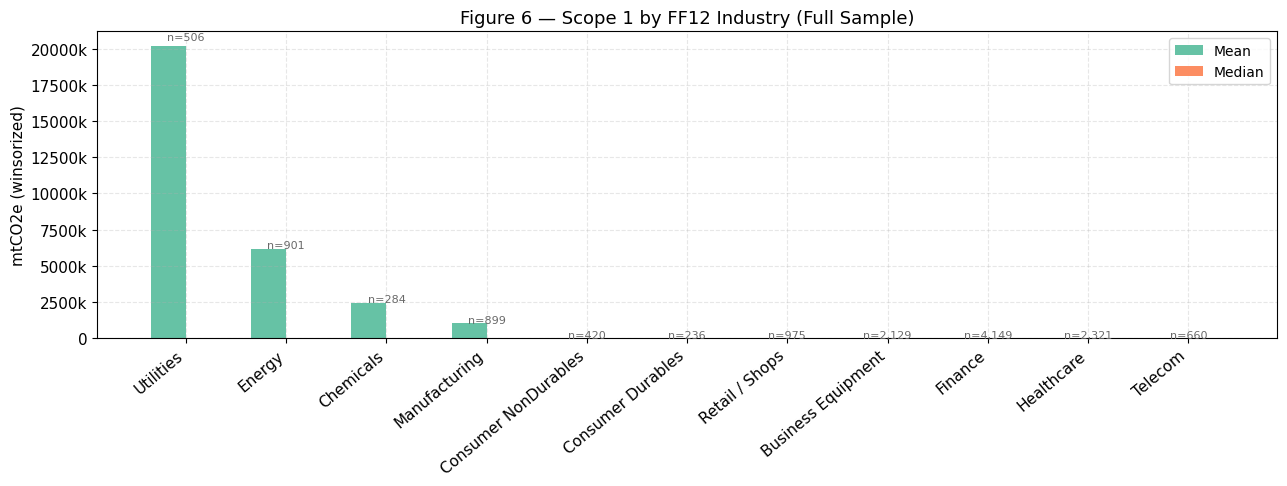

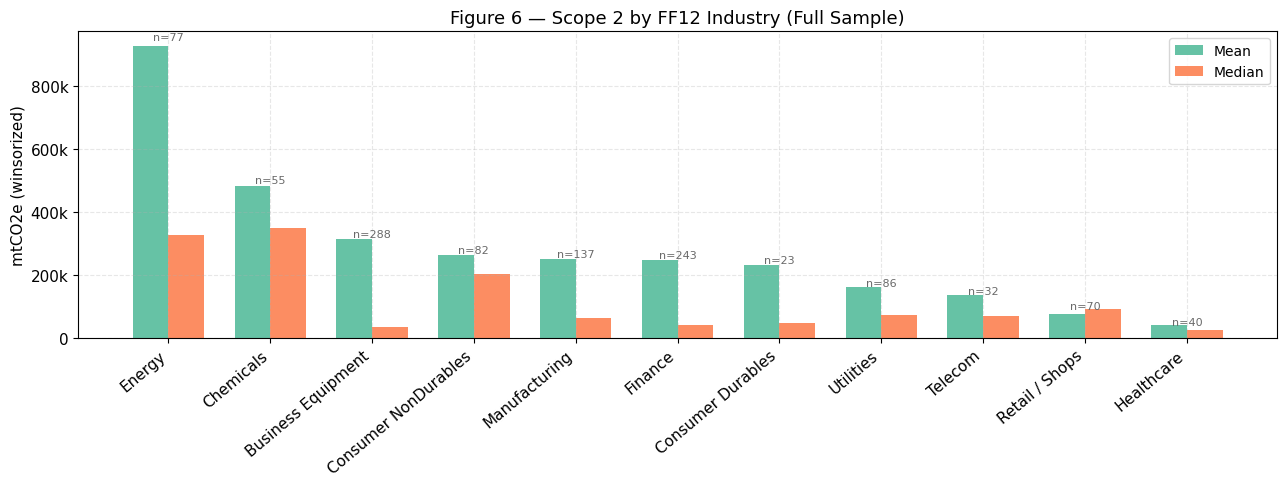

In [22]:
# Cross-sectional bar chart: mean emissions by FF12 industry (most recent year)
df_ff = df[df['ff12'] != '12 Other'].copy() if df['ff12'].nunique() > 1 else df.copy()

scope_pairs = [
    ('scope1_location_total_w', 'Scope 1'),
    ('scope2_final_w',          'Scope 2'),
]

for col, scope_name in scope_pairs:
    if col not in df_ff.columns:
        continue
    ind_stats = (
        df_ff[df_ff[col].notna()]
        .groupby('ff12_label')[col]
        .agg(['mean', 'median', 'count'])
        .sort_values('mean', ascending=False)
    )
    if len(ind_stats) <= 1:
        print(f"[!] Only one FF12 category present ({scope_name}). Add SIC codes to see industry breakdown.")
        continue

    x = np.arange(len(ind_stats))
    w = 0.35
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(x - w/2, ind_stats['mean'],   w, label='Mean',   color=PALETTE[0])
    ax.bar(x + w/2, ind_stats['median'], w, label='Median', color=PALETTE[1])
    ax.set_xticks(x)
    ax.set_xticklabels(ind_stats.index, rotation=40, ha='right')
    ax.set_ylabel('mtCO2e (winsorized)')
    ax.set_title(f'Figure 6 — {scope_name} by FF12 Industry (Full Sample)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e3:.0f}k' if x >= 1000 else f'{x:.0f}'))
    ax.legend()
    # Annotate with sample counts
    for i, (idx, row) in enumerate(ind_stats.iterrows()):
        ax.text(i, max(row['mean'], row['median']) * 1.02, f"n={int(row['count']):,}",
                ha='center', fontsize=8, color='dimgray')
    plt.tight_layout()
    savefig(f'fig6_ff12_{scope_name.lower().replace(" ","_")}')
    plt.show()

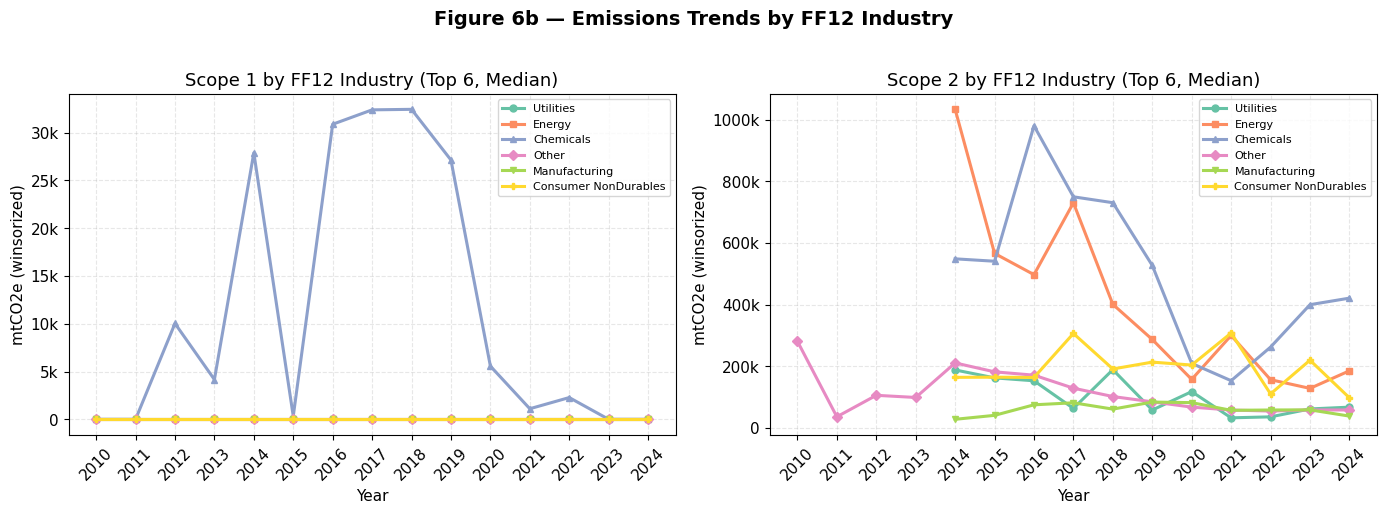

In [23]:
# Industry time trends (top emitting FF12 industries only, to avoid clutter)
if df['ff12'].nunique() > 1:
    top_industries = (
        df.groupby('ff12_label')['scope1_location_total_w'].mean()
        .nlargest(6).index.tolist()
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, col, title in zip(
        axes,
        ['scope1_location_total_w', 'scope2_final_w'],
        ['Scope 1', 'Scope 2'],
    ):
        if col not in df.columns:
            continue
        for i, ind in enumerate(top_industries):
            s = (df[df['ff12_label'] == ind]
                 .groupby('year')[col].median().reindex(years_all))
            ax.plot(s.index, s.values, f'{MARKERS[i]}-', color=PALETTE[i % len(PALETTE)],
                    lw=LINEWIDTH, label=ind, markersize=5)
        ax.set_title(f'{title} by FF12 Industry (Top 6, Median)')
        ax.set_xlabel('Year')
        ax.set_ylabel('mtCO2e (winsorized)')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f'{x/1e3:.0f}k' if x >= 1000 else f'{x:.0f}'))
        ax.legend(fontsize=8)
        ax.set_xticks(years_all)
        ax.tick_params(axis='x', rotation=45)

    fig.suptitle('Figure 6b — Emissions Trends by FF12 Industry', fontsize=14,
                 fontweight='bold', y=1.02)
    plt.tight_layout()
    savefig('fig6b_ff12_trends')
    plt.show()
else:
    print("[!] Add SIC codes to enable industry time-trend chart.")

## 12. Figure 7 — Scope 2 Source Coverage Over Time

Tracks how many firm-years have **reported** Scope 2 (from LSEG) vs. **eGRID-calculated**
Scope 2 vs. **no Scope 2** over time. Helps understand panel data completeness.

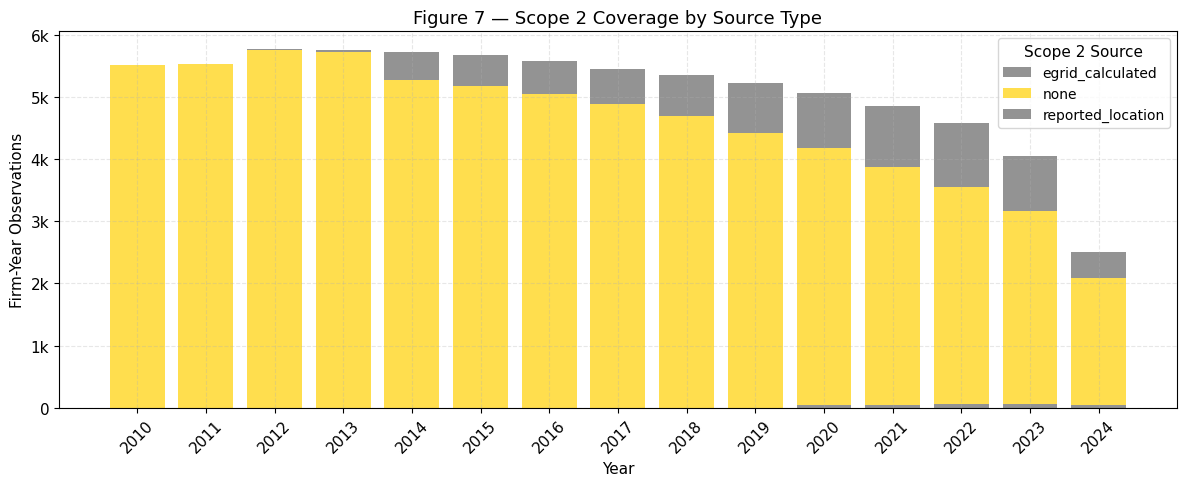

In [17]:
src_counts = (
    df.groupby(['year', 'scope2_source'])
    .size()
    .unstack(fill_value=0)
    .reindex(years_all, fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 5))
src_colors = {'reported': PALETTE[0], 'egrid': PALETTE[2], 'none': PALETTE[5]}
bottom = np.zeros(len(src_counts))

for src in src_counts.columns:
    vals = src_counts[src].values
    ax.bar(src_counts.index, vals, bottom=bottom, label=src,
           color=src_colors.get(src, 'gray'), alpha=0.85)
    bottom += vals

ax.set_title('Figure 7 — Scope 2 Coverage by Source Type')
ax.set_xlabel('Year')
ax.set_ylabel('Firm-Year Observations')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e3:.0f}k' if x >= 1000 else f'{int(x)}'))
ax.legend(title='Scope 2 Source')
ax.set_xticks(years_all)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
savefig('fig7_scope2_coverage')
plt.show()

## 13. Figure 8 — Grid Factor Subgroups × Firm Size

Cross-tabs grid factor (high/low) with firm size (large/small) to show whether the
grid-factor effect on emissions is concentrated in large or small firms.

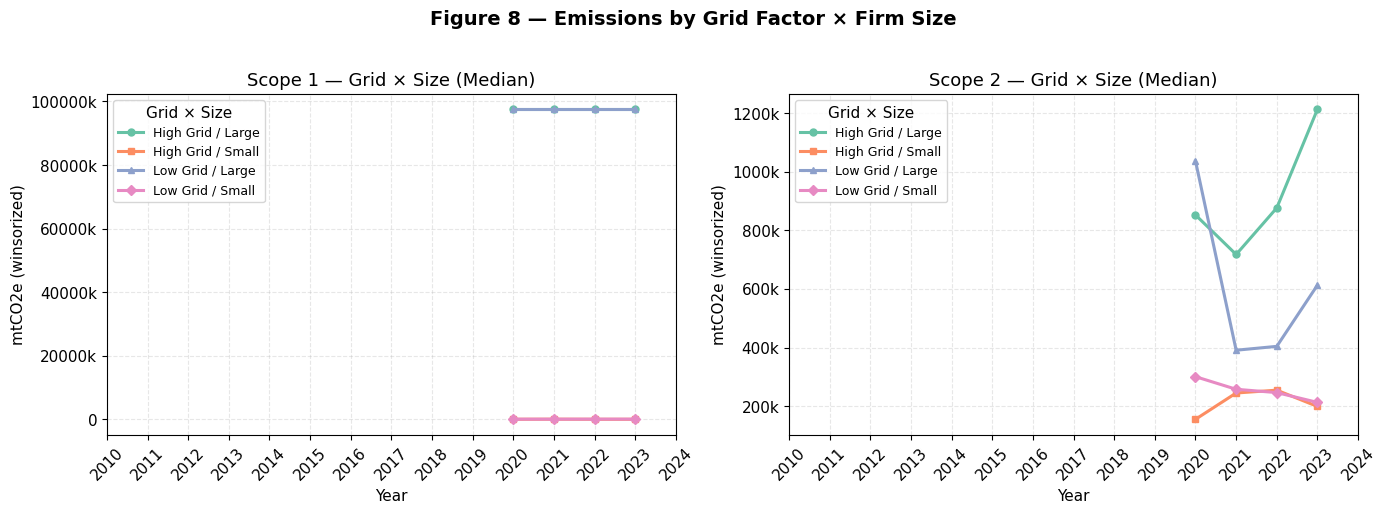

In [18]:
df['grid_x_size'] = np.where(
    df['grid_group'].isna() | df['size_group'].isna(), np.nan,
    df['grid_group'] + ' / ' + df['size_group']
)

GXS_GROUPS  = ['High Grid / Large', 'High Grid / Small',
                'Low Grid / Large',  'Low Grid / Small']
GXS_COLORS  = [PALETTE[0], PALETTE[1], PALETTE[2], PALETTE[3]]
GXS_MARKERS = ['o', 's', '^', 'D']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(
    axes,
    ['scope1_location_total_w', 'scope2_final_w'],
    ['Scope 1', 'Scope 2'],
):
    if col not in df.columns:
        continue
    sub = df[df['grid_x_size'].notna() & df[col].notna()]
    for grp, color, marker in zip(GXS_GROUPS, GXS_COLORS, GXS_MARKERS):
        s = sub[sub['grid_x_size'] == grp].groupby('year')[col].median().reindex(years_all)
        ax.plot(s.index, s.values, f'{marker}-', color=color, lw=LINEWIDTH,
                label=grp, markersize=5)
    ax.set_title(f'{title} — Grid × Size (Median)')
    ax.set_xlabel('Year')
    ax.set_ylabel('mtCO2e (winsorized)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e3:.0f}k' if x >= 1000 else f'{x:.0f}'))
    ax.legend(title='Grid × Size', fontsize=9)
    ax.set_xticks(years_all)
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Figure 8 — Emissions by Grid Factor × Firm Size', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('fig8_grid_x_size')
plt.show()

## 14. Summary Statistics Table

In [19]:
STAT_COLS = {
    'scope1_location_total_w': 'Scope 1 (mtCO2e, winsorized)',
    'scope2_final_w':          'Scope 2 (mtCO2e, winsorized)',
    'energy_use_total_mwh_w':  'Energy Use (MWh, winsorized)',
    'grid_factor':             'Grid Factor (lb CO2e/MWh)',
    'firm_factor':             'Firm Factor (lb CO2e/MWh equiv.)',
}

rows = []
for col, label in STAT_COLS.items():
    if col not in df.columns:
        continue
    s = df[col].dropna()
    rows.append({
        'Variable':  label,
        'N':         f'{len(s):,}',
        'Mean':      f'{s.mean():,.1f}',
        'Median':    f'{s.median():,.1f}',
        'Std Dev':   f'{s.std():,.1f}',
        'P10':       f'{s.quantile(0.10):,.1f}',
        'P90':       f'{s.quantile(0.90):,.1f}',
    })

summary = pd.DataFrame(rows).set_index('Variable')
display(summary)

,N,Mean,Median,Std Dev,P10,P90
Variable,,,,,,
"Scope 1 (mtCO2e, winsorized)","80,633","1,366,128.5",0.0,"10,428,743.8",0.0,0.0
"Scope 2 (mtCO2e, winsorized)","7,738","397,914.8","78,122.5","869,685.6","2,983.3","1,048,270.9"
"Energy Use (MWh, winsorized)","12,685","24,760,370.5","1,904,400.0","75,393,594.3","62,184.8","52,734,800.0"
Grid Factor (lb CO2e/MWh),"1,426",885.4,821.9,396.0,457.5,"1,576.6"
Firm Factor (lb CO2e/MWh equiv.),"12,685","67,712.2",0.0,"3,136,357.5",0.0,111.7


In [20]:
# Summary by grid group
for grp_col, grp_label in [('grid_group', 'Grid Factor Group'),
                             ('size_group', 'Firm Size Group')]:
    print(f"\n{'='*60}")
    print(f"Summary by {grp_label}")
    print('='*60)
    for col, label in [('scope1_location_total_w', 'Scope 1'),
                        ('scope2_final_w', 'Scope 2')]:
        if col not in df.columns:
            continue
        sub = df[df[grp_col].notna() & df[col].notna()]
        tbl = sub.groupby(grp_col)[col].agg(['count', 'mean', 'median'])
        tbl.columns = ['N', f'{label} Mean', f'{label} Median']
        print(f"\n{label}:")
        print(tbl.to_string(float_format=lambda x: f'{x:,.1f}'))


Summary by Grid Factor Group

Scope 1:
              N  Scope 1 Mean  Scope 1 Median
grid_group                                   
High Grid   729  23,500,719.5     1,268,230.8
Low Grid    697  14,380,762.3       619,803.1

Scope 2:
              N  Scope 2 Mean  Scope 2 Median
grid_group                                   
High Grid   342   1,099,170.1       361,417.0
Low Grid    383     715,037.6       357,100.0

Summary by Firm Size Group

Scope 1:
               N  Scope 1 Mean  Scope 1 Median
size_group                                    
Large       1101  75,245,733.3    97,512,591.6
Medium      2031  13,097,207.4     3,823,097.2
Small       1606     441,507.5        91,174.4

Scope 2:
              N  Scope 2 Mean  Scope 2 Median
size_group                                   
Large       386   1,784,331.0     1,086,098.0
Medium      574     801,138.7       499,314.5
Small       382     512,062.4       279,900.0
